<a href="https://colab.research.google.com/github/Monika-disigns/AI-CHATBOT-FOR-CUSTOMER-SUPPORT/blob/main/AI%20chat%20box.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🤖 AI CUSTOMER SUPPORT CHATBOT
NLP + MACHINE LEARNING

📥 Downloading Kaggle dataset...
Using Colab cache for faster access to the 'customer-support-intent-dataset' dataset.

✅ Dataset downloaded!
Dataset location:
/kaggle/input/customer-support-intent-dataset

CSV files found:
 - /kaggle/input/customer-support-intent-dataset/Bitext_Sample_Customer_Service_Training_Dataset.csv
 - /kaggle/input/customer-support-intent-dataset/Bitext_Sample_Customer_Service_Validation_Dataset.csv
 - /kaggle/input/customer-support-intent-dataset/Bitext_Sample_Customer_Service_Testing_Dataset.csv

Using:
/kaggle/input/customer-support-intent-dataset/Bitext_Sample_Customer_Service_Training_Dataset.csv

DATASET INFORMATION
Rows    : 6539
Columns : 4

Columns:
['utterance', 'intent', 'category', 'tags']

First 5 rows:


,utterance,intent,category,tags
0,would it be possible to cancel the order I made?,cancel_order,ORDER,BIP
1,cancelling order,cancel_order,ORDER,BK
2,I need assistance canceling the last order I h...,cancel_order,ORDER,B
3,problem with canceling the order I made,cancel_order,ORDER,B
4,I don't know how to cancel the order I made,cancel_order,ORDER,B



Detected text column:
utterance

Detected intent column:
intent

Final text column:
utterance

Final intent column:
intent

MISSING VALUES
utterance    0
intent       0
category     0
tags         0
dtype: int64

Dataset after removing missing values:
(6539, 4)

✅ Text preprocessing completed!

DATASET SUMMARY
Total records: 6539
Total intents: 27

Intent distribution:
intent
get_invoice                 268
payment_issue               263
check_invoice               258
contact_customer_service    253
complaint                   252
review                      248
check_payment_methods       246
set_up_shipping_address     246
check_cancellation_fee      246
cancel_order                246
track_order                 245
place_order                 243
check_refund_policy         240
get_refund                  239
registration_problems       239
track_refund                239
recover_password            239
newsletter_subscription     238
create_account              237
delivery_per

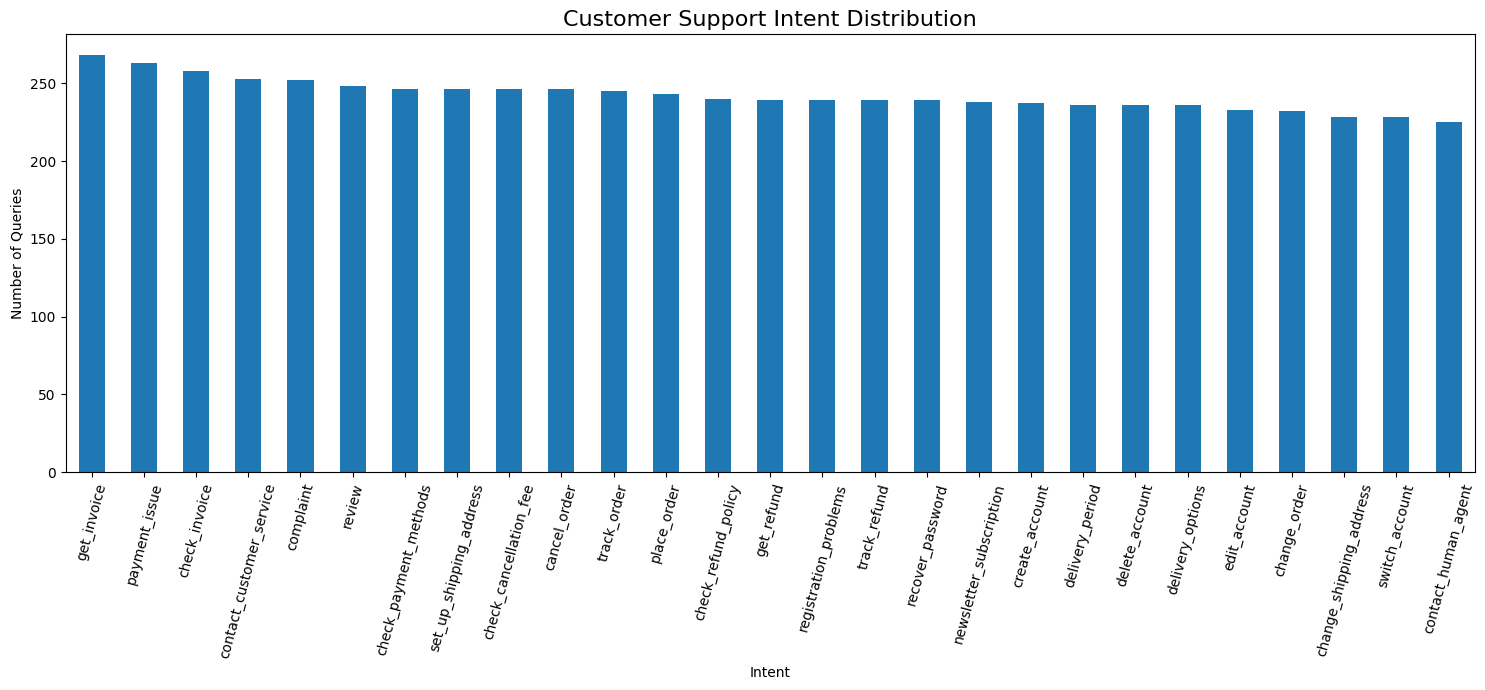

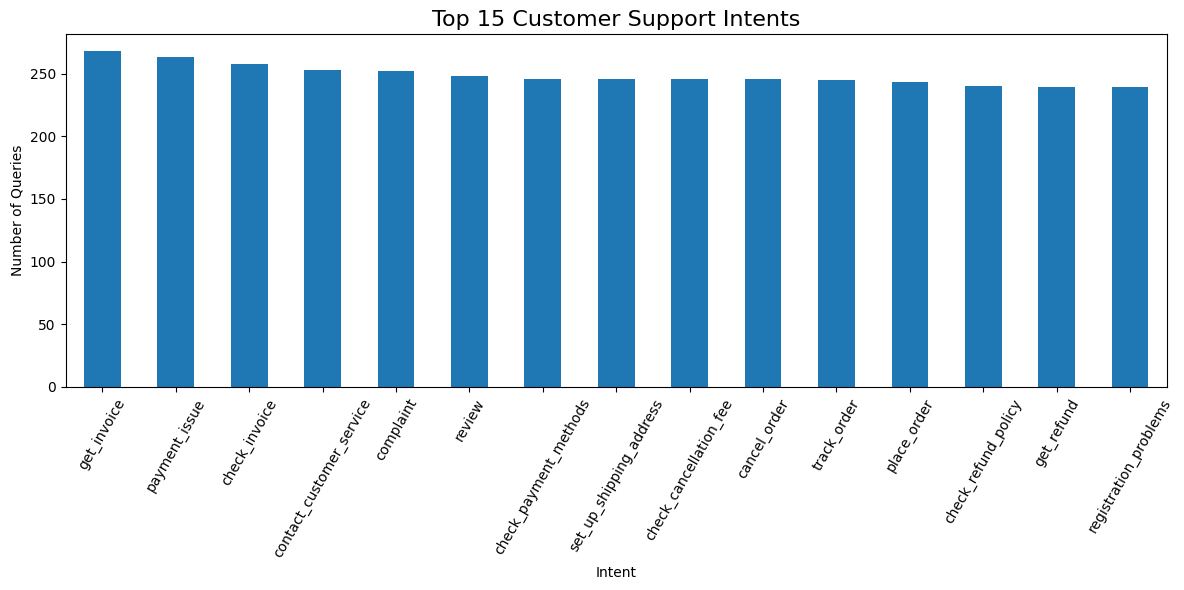


Features: (6539,)
Labels: (6539,)

Training samples:
5231

Testing samples:
1308

MODEL 1: LOGISTIC REGRESSION
Training Logistic Regression...
Accuracy: 99.62 %
F1 Score: 99.62 %

MODEL 2: LINEAR SVM
Training Linear SVM...
Accuracy: 99.69 %
F1 Score: 99.69 %

MODEL 3: NAIVE BAYES
Training Naive Bayes...
Accuracy: 99.01 %
F1 Score: 99.01 %

MODEL 4: RANDOM FOREST
Training Random Forest...
Accuracy: 98.85 %
F1 Score: 98.85 %

MODEL COMPARISON


,Model,Accuracy (%),F1 Score (%)
1,Linear SVM,99.69,99.69
0,Logistic Regression,99.62,99.62
2,Naive Bayes,99.01,99.01
3,Random Forest,98.85,98.85


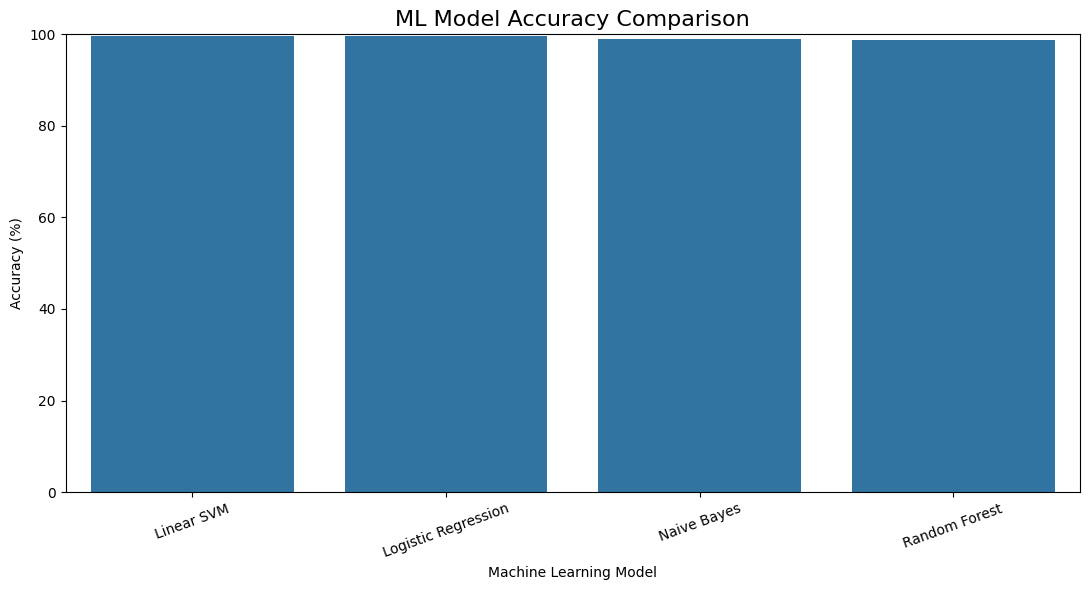


🏆 BEST MODEL: Linear SVM
🏆 ACCURACY: 99.69 %

CLASSIFICATION REPORT
                          precision    recall  f1-score   support

            cancel_order       1.00      0.98      0.99        49
            change_order       1.00      1.00      1.00        46
 change_shipping_address       1.00      1.00      1.00        45
  check_cancellation_fee       0.98      1.00      0.99        49
           check_invoice       1.00      1.00      1.00        52
   check_payment_methods       1.00      1.00      1.00        49
     check_refund_policy       0.98      1.00      0.99        48
               complaint       1.00      1.00      1.00        50
contact_customer_service       1.00      1.00      1.00        51
     contact_human_agent       1.00      1.00      1.00        45
          create_account       0.98      1.00      0.99        47
          delete_account       1.00      0.98      0.99        47
        delivery_options       1.00      1.00      1.00        47
      

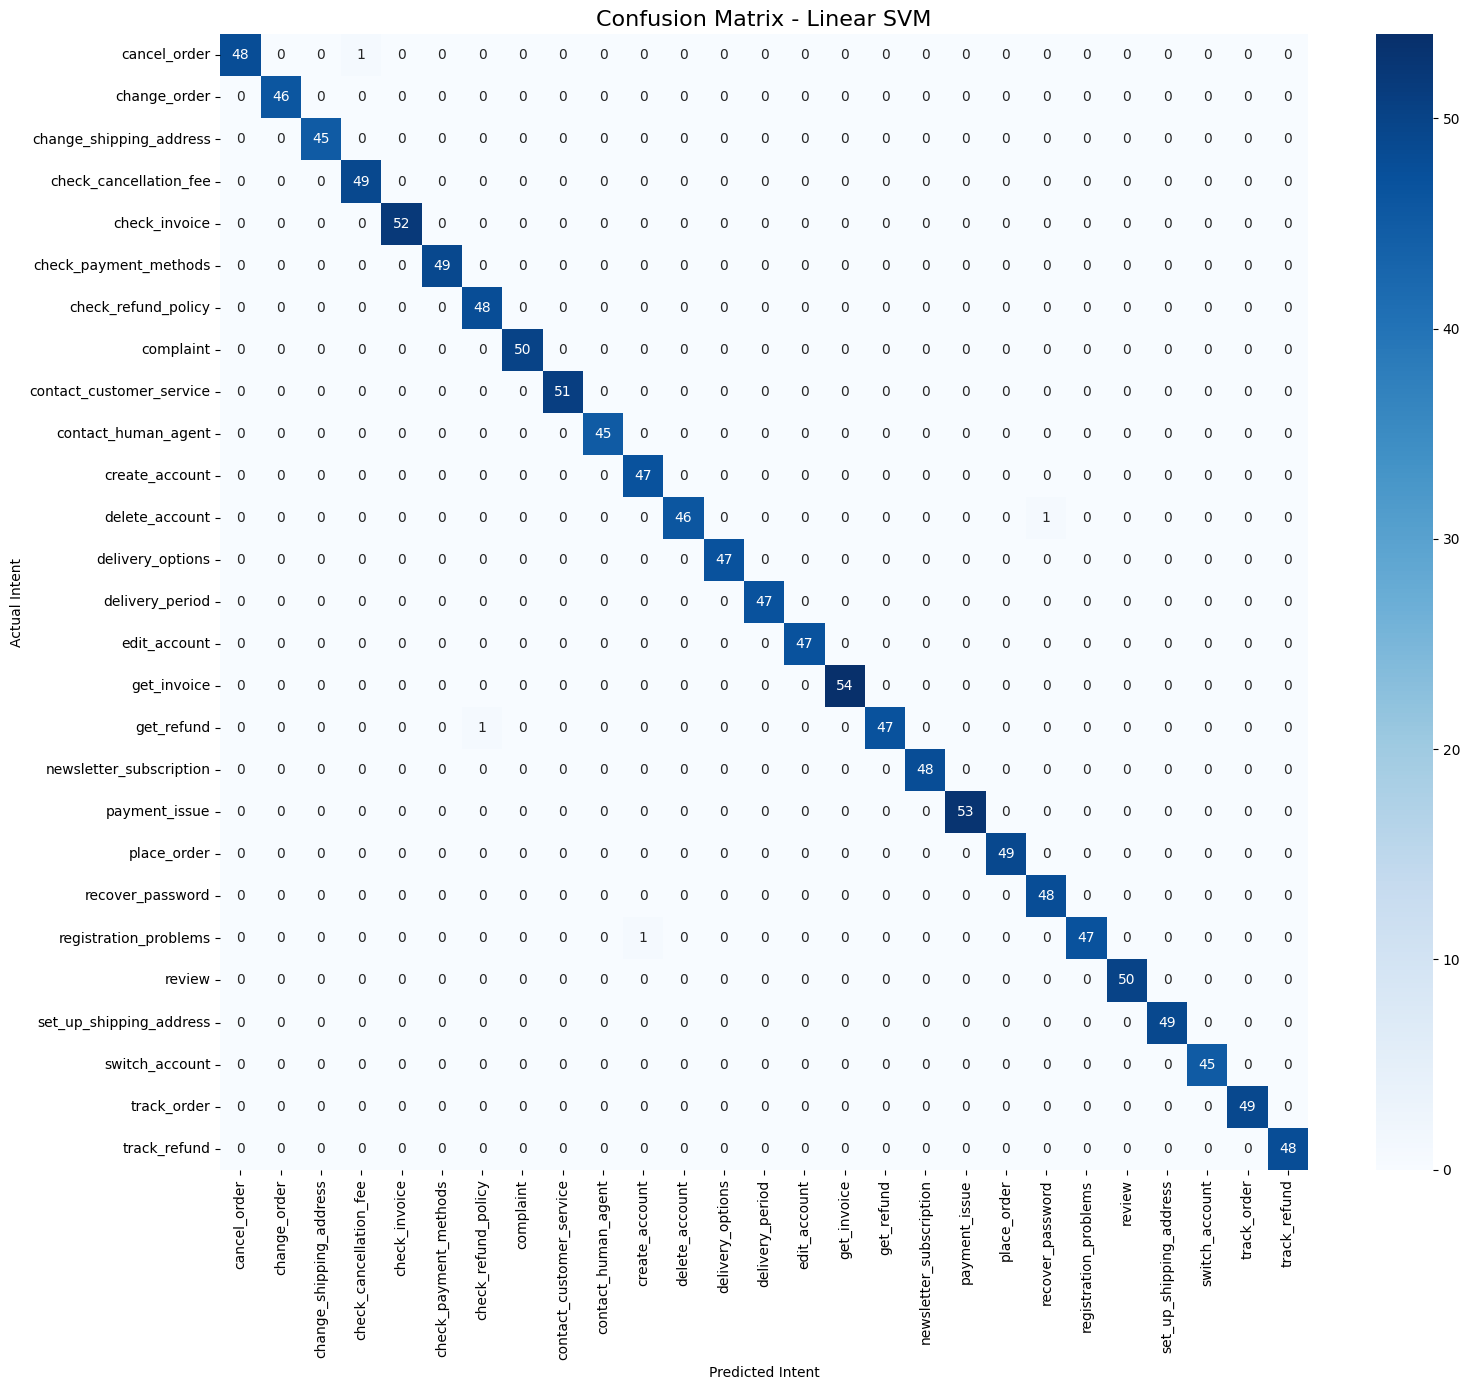


🤖 CHATBOT TEST

👤 User:
Where is my order?

🎯 Predicted Intent:
track_order

🤖 Bot:
Sure! Please provide your order ID so I can help track your order.
----------------------------------------------------------------------

👤 User:
I want to cancel my order

🎯 Predicted Intent:
cancel_order

🤖 Bot:
Sure! I can help you cancel your order. Please provide your order ID.
----------------------------------------------------------------------

👤 User:
I forgot my password

🎯 Predicted Intent:
recover_password

🤖 Bot:
You can reset your password using the password recovery option.
----------------------------------------------------------------------

👤 User:
I want a refund

🎯 Predicted Intent:
get_refund

🤖 Bot:
I understand that you need help with Get refund. Please provide more details so I can assist you.
----------------------------------------------------------------------

👤 User:
I have a payment problem

🎯 Predicted Intent:
payment_issue

🤖 Bot:
I'm sorry you are facing a payment is

In [22]:
# ================================================================
# 🤖 AI CHATBOT FOR CUSTOMER SUPPORT
# Machine Learning + NLP
#
# Dataset:
# https://www.kaggle.com/datasets/scodepy/customer-support-intent-dataset
#
# Google Colab - COMPLETE ONE CELL CODE
# ================================================================


# ================================================================
# 1. INSTALL REQUIRED LIBRARIES
# ================================================================

!pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn joblib


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import glob
import re
import joblib
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


print("=" * 70)
print("🤖 AI CUSTOMER SUPPORT CHATBOT")
print("NLP + MACHINE LEARNING")
print("=" * 70)


# ================================================================
# 3. DOWNLOAD YOUR KAGGLE DATASET AUTOMATICALLY
# ================================================================

print("\n📥 Downloading Kaggle dataset...")

path = kagglehub.dataset_download(
    "scodepy/customer-support-intent-dataset"
)

print("\n✅ Dataset downloaded!")
print("Dataset location:")
print(path)


# ================================================================
# 4. FIND CSV FILE
# ================================================================

csv_files = glob.glob(
    os.path.join(path, "**", "*.csv"),
    recursive=True
)

if len(csv_files) == 0:

    raise FileNotFoundError(
        "❌ No CSV file found in the downloaded dataset."
    )

print("\nCSV files found:")

for file in csv_files:
    print(" -", file)


# Use the first CSV
csv_file = csv_files[0]

print("\nUsing:")
print(csv_file)


# ================================================================
# 5. LOAD DATASET
# ================================================================

df = pd.read_csv(csv_file)

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


# ================================================================
# 6. AUTOMATICALLY DETECT TEXT AND INTENT COLUMNS
# ================================================================

columns_lower = {
    str(col).strip().lower(): col
    for col in df.columns
}


# Possible customer-query columns
text_candidates = [
    "text",
    "query",
    "question",
    "utterance",
    "instruction",
    "message",
    "customer_query",
    "customer_message",
    "input",
    "request"
]


# Possible intent columns
intent_candidates = [
    "intent",
    "label",
    "category",
    "class",
    "target"
]


text_column = None
intent_column = None


# Find text column
for col in text_candidates:

    if col in columns_lower:

        text_column = columns_lower[col]

        break


# Find intent column
for col in intent_candidates:

    if col in columns_lower:

        intent_column = columns_lower[col]

        break


print("\nDetected text column:")
print(text_column)

print("\nDetected intent column:")
print(intent_column)


# ================================================================
# 7. FALLBACK AUTOMATIC DETECTION
# ================================================================

if text_column is None:

    # Find object/string columns
    object_columns = df.select_dtypes(
        include=["object"]
    ).columns.tolist()

    if len(object_columns) > 0:

        # Select the column with longest average text
        avg_lengths = {}

        for col in object_columns:

            avg_lengths[col] = (
                df[col]
                .astype(str)
                .str.len()
                .mean()
            )

        text_column = max(
            avg_lengths,
            key=avg_lengths.get
        )


if intent_column is None:

    object_columns = df.select_dtypes(
        include=["object"]
    ).columns.tolist()

    possible = []

    for col in object_columns:

        unique_count = df[col].nunique()

        if unique_count < len(df) * 0.2:

            possible.append(col)

    if len(possible) > 0:

        intent_column = possible[-1]


print("\nFinal text column:")
print(text_column)

print("\nFinal intent column:")
print(intent_column)


if text_column is None or intent_column is None:

    print("\n❌ Could not detect dataset columns.")

    print(
        "Available columns:",
        df.columns.tolist()
    )

    raise ValueError(
        "Please check the dataset column names."
    )


# ================================================================
# 8. MISSING VALUES
# ================================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())


df = df.dropna(
    subset=[
        text_column,
        intent_column
    ]
)


# Remove duplicates
df = df.drop_duplicates(
    subset=[
        text_column,
        intent_column
    ]
)


print("\nDataset after removing missing values:")
print(df.shape)


# ================================================================
# 9. TEXT PREPROCESSING
# ================================================================

def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # remove HTML
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # remove punctuation
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    # remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


df["clean_text"] = df[
    text_column
].apply(clean_text)


# Remove empty text
df = df[
    df["clean_text"].str.len() > 0
]


print("\n✅ Text preprocessing completed!")


# ================================================================
# 10. DATASET SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(
    "Total records:",
    len(df)
)

print(
    "Total intents:",
    df[intent_column].nunique()
)

print(
    "\nIntent distribution:"
)

print(
    df[intent_column].value_counts()
)


# ================================================================
# 11. GRAPH 1 - INTENT DISTRIBUTION
# ================================================================

plt.figure(figsize=(15, 7))

df[intent_column].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Support Intent Distribution",
    fontsize=16
)

plt.xlabel("Intent")
plt.ylabel("Number of Queries")

plt.xticks(
    rotation=75
)

plt.tight_layout()

plt.show()


# ================================================================
# 12. GRAPH 2 - TOP INTENTS
# ================================================================

plt.figure(figsize=(12, 6))

df[intent_column].value_counts().head(15).plot(
    kind="bar"
)

plt.title(
    "Top 15 Customer Support Intents",
    fontsize=16
)

plt.xlabel("Intent")
plt.ylabel("Number of Queries")

plt.xticks(
    rotation=60
)

plt.tight_layout()

plt.show()


# ================================================================
# 13. PREPARE X AND Y
# ================================================================

X = df["clean_text"]

y = df[intent_column].astype(str)


print("\nFeatures:", X.shape)
print("Labels:", y.shape)


# ================================================================
# 14. TRAIN / TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\nTraining samples:")
print(len(X_train))

print("\nTesting samples:")
print(len(X_test))


# ================================================================
# 15. MODEL 1 - LOGISTIC REGRESSION
# ================================================================

print("\n" + "=" * 70)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 70)


logistic_model = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            lowercase=True,

            ngram_range=(1, 2),

            min_df=2,

            max_df=0.95,

            sublinear_tf=True,

            max_features=50000
        )
    ),

    (
        "classifier",

        LogisticRegression(

            max_iter=2000,

            C=5,

            class_weight="balanced"
        )
    )
])


print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)


logistic_pred = logistic_model.predict(
    X_test
)


logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)


logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    average="weighted"
)


print(
    "Accuracy:",
    round(
        logistic_accuracy * 100,
        2
    ),
    "%"
)

print(
    "F1 Score:",
    round(
        logistic_f1 * 100,
        2
    ),
    "%"
)


# ================================================================
# 16. MODEL 2 - LINEAR SVM
# ================================================================

print("\n" + "=" * 70)
print("MODEL 2: LINEAR SVM")
print("=" * 70)


svm_model = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            lowercase=True,

            ngram_range=(1, 2),

            min_df=2,

            max_df=0.95,

            sublinear_tf=True,

            max_features=50000
        )
    ),

    (
        "classifier",

        LinearSVC(

            C=2,

            class_weight="balanced"
        )
    )
])


print("Training Linear SVM...")


svm_model.fit(
    X_train,
    y_train
)


svm_pred = svm_model.predict(
    X_test
)


svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)


svm_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted"
)


print(
    "Accuracy:",
    round(
        svm_accuracy * 100,
        2
    ),
    "%"
)

print(
    "F1 Score:",
    round(
        svm_f1 * 100,
        2
    ),
    "%"
)


# ================================================================
# 17. MODEL 3 - NAIVE BAYES
# ================================================================

print("\n" + "=" * 70)
print("MODEL 3: NAIVE BAYES")
print("=" * 70)


nb_model = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            lowercase=True,

            ngram_range=(1, 2),

            min_df=2,

            max_features=50000
        )
    ),

    (
        "classifier",

        MultinomialNB(
            alpha=0.1
        )
    )
])


print("Training Naive Bayes...")


nb_model.fit(
    X_train,
    y_train
)


nb_pred = nb_model.predict(
    X_test
)


nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)


nb_f1 = f1_score(
    y_test,
    nb_pred,
    average="weighted"
)


print(
    "Accuracy:",
    round(
        nb_accuracy * 100,
        2
    ),
    "%"
)

print(
    "F1 Score:",
    round(
        nb_f1 * 100,
        2
    ),
    "%"
)


# ================================================================
# 18. MODEL 4 - RANDOM FOREST
# ================================================================

print("\n" + "=" * 70)
print("MODEL 4: RANDOM FOREST")
print("=" * 70)


rf_model = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            lowercase=True,

            ngram_range=(1, 2),

            min_df=2,

            max_features=30000
        )
    ),

    (
        "classifier",

        RandomForestClassifier(

            n_estimators=200,

            random_state=42,

            n_jobs=-1,

            class_weight="balanced"
        )
    )
])


print("Training Random Forest...")


rf_model.fit(
    X_train,
    y_train
)


rf_pred = rf_model.predict(
    X_test
)


rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)


rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)


print(
    "Accuracy:",
    round(
        rf_accuracy * 100,
        2
    ),
    "%"
)

print(
    "F1 Score:",
    round(
        rf_f1 * 100,
        2
    ),
    "%"
)


# ================================================================
# 19. MODEL COMPARISON
# ================================================================

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)


results = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Linear SVM",

        "Naive Bayes",

        "Random Forest"
    ],

    "Accuracy": [

        logistic_accuracy,

        svm_accuracy,

        nb_accuracy,

        rf_accuracy
    ],

    "F1 Score": [

        logistic_f1,

        svm_f1,

        nb_f1,

        rf_f1
    ]
})


results["Accuracy (%)"] = (
    results["Accuracy"] * 100
).round(2)


results["F1 Score (%)"] = (
    results["F1 Score"] * 100
).round(2)


results = results.sort_values(
    "Accuracy",
    ascending=False
)


display(
    results[
        [
            "Model",
            "Accuracy (%)",
            "F1 Score (%)"
        ]
    ]
)


# ================================================================
# 20. MODEL COMPARISON GRAPH
# ================================================================

plt.figure(figsize=(11, 6))


sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)"
)


plt.title(
    "ML Model Accuracy Comparison",
    fontsize=16
)

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ================================================================
# 21. SELECT BEST MODEL
# ================================================================

models = {

    "Logistic Regression":
        logistic_model,

    "Linear SVM":
        svm_model,

    "Naive Bayes":
        nb_model,

    "Random Forest":
        rf_model
}


accuracies = {

    "Logistic Regression":
        logistic_accuracy,

    "Linear SVM":
        svm_accuracy,

    "Naive Bayes":
        nb_accuracy,

    "Random Forest":
        rf_accuracy
}


best_model_name = max(
    accuracies,
    key=accuracies.get
)


best_model = models[
    best_model_name
]


best_accuracy = accuracies[
    best_model_name
]


print("\n" + "=" * 70)

print(
    "🏆 BEST MODEL:",
    best_model_name
)

print(
    "🏆 ACCURACY:",
    round(
        best_accuracy * 100,
        2
    ),
    "%"
)

print("=" * 70)


# ================================================================
# 22. CLASSIFICATION REPORT
# ================================================================

best_predictions = best_model.predict(
    X_test
)


print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)


# ================================================================
# 23. CONFUSION MATRIX
# ================================================================

labels = sorted(
    y_test.unique()
)


cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=labels
)


plt.figure(figsize=(16, 14))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)


plt.title(
    "Confusion Matrix - " +
    best_model_name,
    fontsize=16
)


plt.xlabel(
    "Predicted Intent"
)

plt.ylabel(
    "Actual Intent"
)


plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)


plt.tight_layout()

plt.show()


# ================================================================
# 24. CREATE RESPONSE DATABASE
# ================================================================

# Generic responses for customer support intents.
# If your dataset uses a different intent name,
# the fallback response below will automatically be used.


responses = {

    "cancel_order":
        "Sure! I can help you cancel your order. Please provide your order ID.",

    "track_order":
        "Sure! Please provide your order ID so I can help track your order.",

    "order_status":
        "Please provide your order ID so I can check the order status.",

    "place_order":
        "Sure! Please tell me which product you would like to order.",

    "change_order":
        "I can help you change your order. Please provide your order ID.",

    "payment_issue":
        "I'm sorry you are facing a payment issue. Please provide more details.",

    "payment":
        "We support several payment methods. Please check the available options during checkout.",

    "refund":
        "Please provide your order details so I can help you with your refund.",

    "track_refund":
        "Please provide your refund details so I can check the refund status.",

    "complaint":
        "I'm sorry you are experiencing a problem. Please describe the issue and we will help you.",

    "review":
        "Thank you for your feedback! We really appreciate it.",

    "contact_human_agent":
        "Sure! I'll help you connect with a customer-support representative.",

    "contact_customer_service":
        "Please contact our customer-support team for further assistance.",

    "recover_password":
        "You can reset your password using the password recovery option.",

    "registration_problems":
        "I'm sorry you are having trouble registering. Please check your details and try again.",

    "create_account":
        "You can create an account using the registration page.",

    "delete_account":
        "You can request account deletion through your account settings.",

    "edit_account":
        "You can update your account information from your profile settings.",

    "delivery_options":
        "Please check the available delivery options for your location.",

    "delivery_period":
        "Delivery time depends on your location and selected delivery option.",

    "change_shipping_address":
        "Please provide your order ID and the new shipping address.",

    "set_up_shipping_address":
        "You can add a shipping address from your account settings.",

    "check_invoice":
        "Please provide your invoice details so I can help you.",

    "get_invoice":
        "You can download your invoice from your order details.",

    "check_cancellation_fee":
        "Please provide your order details so we can check whether a cancellation fee applies.",

    "newsletter_subscription":
        "You can manage your newsletter subscription from your account settings."
}


# ================================================================
# 25. RESPONSE FUNCTION
# ================================================================

def get_response(intent):

    if intent in responses:

        return responses[intent]


    readable_intent = (
        str(intent)
        .replace("_", " ")
        .capitalize()
    )


    return (
        "I understand that you need help with "
        + readable_intent
        + ". Please provide more details so I can assist you."
    )


# ================================================================
# 26. CHATBOT FUNCTION
# ================================================================

def chatbot(user_message):

    cleaned_message = clean_text(
        user_message
    )


    predicted_intent = best_model.predict(
        [cleaned_message]
    )[0]


    response = get_response(
        predicted_intent
    )


    return predicted_intent, response


# ================================================================
# 27. TEST CHATBOT
# ================================================================

print("\n" + "=" * 70)
print("🤖 CHATBOT TEST")
print("=" * 70)


test_questions = [

    "Where is my order?",

    "I want to cancel my order",

    "I forgot my password",

    "I want a refund",

    "I have a payment problem",

    "I want to speak to a human",

    "How long will delivery take?",

    "I want to create an account",

    "I want to give feedback",

    "I have a complaint"
]


for question in test_questions:

    intent, response = chatbot(
        question
    )


    print("\n👤 User:")
    print(question)


    print("\n🎯 Predicted Intent:")
    print(intent)


    print("\n🤖 Bot:")
    print(response)


    print("-" * 70)


# ================================================================
# 28. SAVE TRAINED MODEL
# ================================================================

joblib.dump(
    best_model,
    "customer_support_chatbot_model.pkl"
)


joblib.dump(
    responses,
    "chatbot_responses.pkl"
)


print("\n✅ Model saved successfully!")

print(
    "customer_support_chatbot_model.pkl"
)

print(
    "chatbot_responses.pkl"
)


# ================================================================
# 29. SAVE PROCESSED DATASET
# ================================================================

df.to_csv(
    "processed_customer_support_dataset.csv",
    index=False
)


print(
    "processed_customer_support_dataset.csv saved!"
)


# ================================================================
# 30. FINAL INTERACTIVE CHATBOT
# ================================================================

print("\n")
print("=" * 70)
print("🤖 AI CUSTOMER SUPPORT CHATBOT")
print("=" * 70)

print(
    "Ask your customer-support question."
)

print(
    "Type 'exit' to stop."
)

print("=" * 70)


while True:

    user_input = input(
        "\n👤 You: "
    )


    if user_input.lower().strip() == "exit":

        print(
            "\n🤖 Bot: Thank you for contacting us! "
            "Have a great day! 👋"
        )

        break


    if user_input.strip() == "":

        print(
            "🤖 Bot: Please enter a question."
        )

        continue


    intent, response = chatbot(
        user_input
    )


    print(
        "🎯 Intent:",
        intent
    )


    print(
        "🤖 Bot:",
        response
    )